# Проект Телекоммуникации

Оператор связи «ТелеДом» хочет снизить отток клиентов. Если заранее увидеть, что абонент, скорее всего, собирается расторгнуть договор, ему можно вовремя предложить промокод, скидку или специальные условия — и часть клиентов удастся удержать.

В этом проекте я буду строить модель машинного обучения, которая предскажет, **разорвёт ли абонент договор или останется**. Это задача классификации, 

Для работы у меня есть данные из нескольких источников (разные файлы), которые нужно аккуратно объединить по ключу customerID:

- contract_new.csv — всё про договор и оплату: даты начала/окончания, тип оплаты, способ платежа, ежемесячные и общие начисления и т.д.
- personal_new.csv — базовые характеристики клиента: пол, пенсионер/не пенсионер, наличие партнёра, дети.
- internet_new.csv — интернет и дополнительные сервисы: тип подключения (DSL/Fiber optic), безопасность, резервное копирование, техподдержка, стриминговые услуги.
- phone_new.csv — телефония: например, подключение к нескольким линиям.

Отдельно важно: данные по договорам актуальны на 1 февраля 2020 года — это мой “срез”, относительно которого я буду формировать целевой признак и строить прогноз.

————————

План работы:

 1) Загрузка данных и первичный осмотр
- Загружу все таблицы и быстро проверю: размеры, типы данных, пропуски, дубликаты.
- Посмотрю, насколько корректно выглядит ключ customerID и совпадают ли клиенты между файлами.

 2) Анализ и предобработка каждого датасета отдельно
- Приведу форматы данных к нормальному виду (особенно даты и денежные признаки).
- Разберусь с пропусками и странными значениями.
- Оценю, какие признаки точно пригодятся для модели, а какие могут быть бесполезными или проблемными.

 3) Объединение данных
- Соберу единый датафрейм по customerID.
- Проверю, не потерялись ли клиенты при объединении, и почему (если потерялись).

 4) EDA и предобработка уже общего датасета
- Посмотрю распределения признаков и их связь с оттоком.
- Сделаю корреляционный анализ, чтобы понимать, нет ли сильных зависимостей/дублей.
- При необходимости сгенерирую новые признаки — например:
  ⦁ длительность договора (по датам),
  ⦁ количество подключённых услуг,
  ⦁ “пакеты” услуг (например, наличие стримингов/безопасности/техподдержки как группа).

 5) Подготовка данных для обучения
- Разделю данные на train/test.
- Настрою преобразования признаков (кодирование категорий, масштабирование числовых — где нужно) так, чтобы не было утечек из test в train.
- Соберу всё в аккуратный пайплайн, чтобы обучение было воспроизводимым.

 6) Обучение моделей
- Обучу как минимум две модели и сравню их качество.
- Для одной из моделей подберу минимум два гиперпараметра, чтобы попытаться улучшить результат.

 7) Выбор лучшей модели и финальная проверка
- Выберу лучшую модель по качеству и проверю её на тестовой выборке.
- Зафиксирую итоговую метрику и основные выводы по ошибкам (где модель чаще ошибается и почему).

 8) Итоговый вывод и рекомендации
- Подведу итоги по проекту: что сделано и что получилось.
- Сформулирую рекомендации для бизнеса: на какие группы клиентов стоит обратить внимание, какие признаки сильнее всего сигнализируют о риске ухода, и как можно использовать модель для удержания.

## Загрузка данных

In [1]:
pip install phik

     |████████████████████████████████| 677 kB 2.4 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install shap

     |████████████████████████████████| 999 kB 1.5 MB/s eta 0:00:01


In [3]:
pip install -U scikit-learn

     |████████████████████████████████| 13.5 MB 2.5 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 62.7 MB/s eta 0:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install -U lightgbm

     |████████████████████████████████| 3.6 MB 2.7 MB/s eta 0:00:01
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 3.3.1
    Uninstalling lightgbm-3.3.1:
      Successfully uninstalled lightgbm-3.3.1
Note: you may need to restart the kernel to use updated packages.


In [5]:
# импортируем необходимые модули и библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from phik import phik_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
import shap
import warnings

In [6]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
# прочитаем имеющиеся датасеты
contract = pd.read_csv('/datasets/contract_new.csv') # информация о договор
personal = pd.read_csv('/datasets/personal_new.csv') # персональные данные клиента
internet = pd.read_csv('/datasets/internet_new.csv') # информация об интернет-услугах
phone = pd.read_csv('/datasets/phone_new.csv') # информация об услугах телефонии

In [8]:
contract.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5
5,9305-CDSKC,2019-03-01,No,Month-to-month,Yes,Electronic check,99.65,1150.96
6,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,2058.21
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,300.48
8,7892-POOKP,2017-07-01,No,Month-to-month,Yes,Electronic check,104.80,3573.68
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35


In [9]:
personal.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes


In [10]:
internet.head(10)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [11]:
phone.head(10)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


In [12]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [13]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [14]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [15]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


### Вывод: 

При первичном осмотре данных я ознакомилась с колонками датасетов, получилось вникнуть в структуру данных и значения. Датасеты не имеют пропусков. Датасет 'contract' нуждается в изменении типов данных

## Предобработка данных и исследовательский анализ отдельных датасетов


### Изменение типов данных

In [16]:
# изменение типа данных в колонке 'BeginDate' на datetime
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

Изменить тип данных в колонке 'EndDate' сейчас невозможно, так как в ней содержится значение "No" для пользователей, продолжающих пользоваться связью. Самое время создать таргетный признак 'IsBrokenContract' (расторгнутый контракт), в котором 1 будет означать, что контракт расторгнут, а 0 - активный контракт

In [17]:
contract['IsBrokenContract'] = (contract['EndDate'] != "No").astype(int)

Теперь можно изменить тип данных в колонке 'EndDate' на datetime c параметром errors='coerce'

In [18]:
contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')

In [19]:
# изменение типа данных в колонке 'MonthlyCharges' на float
contract['MonthlyCharges'] = contract['MonthlyCharges'].astype('float')

При изменении типа данных в колонке 'TotalCharges' возникает ошибка, так как этот столбец содержит строки, состоящие из пробелов. Проверим их

In [20]:
# посчитаем количество строк с пустым значением
(contract['TotalCharges'].astype(str).str.strip() == "").sum()

11

In [21]:
# выведем строки датасета, в которых 'TotalCharges' - пустое
s = contract['TotalCharges'].astype(str)
mask = s.str.strip().eq('')
contract[mask]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,IsBrokenContract
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,,0
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,,0
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,,0
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,,0
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,,0
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,,0
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,,0
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,,0
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,,0
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,,0


Все пользователи из таких строк заключили контракт 01.02.2020, что является датой получения среза, следовательно, колонка 'TotalCharges' для них еще не успела накопиться, на месте пропусков должен быть 0

In [22]:
contract["TotalCharges"] = pd.to_numeric(contract["TotalCharges"], errors="coerce").fillna(0)

Я сменила типы данных в колонках 'BeginDate' и 'EndDate' на datetime, предварительно создав целевой признак - 'IsBrokenContract', обработала пропуски в колонке 'TotalCharges' и изменила тип данных в колонках 'TotalCharges' и 'MonthlyCharges' на 'float'

### Проверка данных на дубликаты

Проверим наличие явных дубликатов в колонке 'customerID', чтобы исключить ситуацию, в которой для одного пользователя будет несколько записей в датасете. Если нет явных дубликатов в этих столбцах, то их не будет и во всем датасете

In [23]:
contract['customerID'].duplicated().sum()

0

In [24]:
personal['customerID'].duplicated().sum()

0

In [25]:
internet['customerID'].duplicated().sum()

0

In [26]:
phone['customerID'].duplicated().sum()

0

Проверим некоторые столбцы датасетов на неявные дубликаты

In [27]:
# создадим функцию для отслеживания неявных дубликатов
def check_duplicates(data):
    for column in data.select_dtypes(include='object'):
        if column != 'customerID':
            print(f"{column:<20}:  {data[column].unique()}")  

In [28]:
check_duplicates(contract)

Type                :  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling    :  ['Yes' 'No']
PaymentMethod       :  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [29]:
check_duplicates(personal)

gender              :  ['Female' 'Male']
Partner             :  ['Yes' 'No']
Dependents          :  ['No' 'Yes']


In [30]:
check_duplicates(internet)

InternetService     :  ['DSL' 'Fiber optic']
OnlineSecurity      :  ['No' 'Yes']
OnlineBackup        :  ['Yes' 'No']
DeviceProtection    :  ['No' 'Yes']
TechSupport         :  ['No' 'Yes']
StreamingTV         :  ['No' 'Yes']
StreamingMovies     :  ['No' 'Yes']


In [31]:
check_duplicates(phone)

MultipleLines       :  ['No' 'Yes']


В данных нет явных и неявных дубликатов

### Вывод по преобработке данных:

В ходе предобработки выяснилось, что столбец EndDate нельзя сразу привести к типу datetime, так как у активных клиентов там встречается значение "No". Поэтому сначала был создан целевой признак IsBrokenContract: 1 — договор расторгнут, 0 — договор активен, после чего EndDate удалось преобразовать в формат даты с использованием errors='coerce'.

При попытке привести TotalCharges к числовому типу обнаружились значения из пробелов; проверка показала, что эти записи относятся к клиентам, начавшим обслуживание 01.02.2020 (дата среза), поэтому общие начисления у них ещё не накопились и пропуски корректно заменены на 0. В результате типы данных в BeginDate и EndDate были приведены к datetime, а MonthlyCharges и TotalCharges — к float.

Дополнительно выполнена проверка на дубликаты: явные (по customerID) и неявные (через check_duplicates) — дубликатов в данных не выявлено.

### Исследовательский анализ датасета 'contract'

In [32]:
# создадим функцию для исследовательского анализа данных
def analyze_distribution(data, column):
    num_columns_data = data.select_dtypes(include='float').columns.to_list()
    name = (column
        .replace('_', ' ')
        .capitalize())
    
    if column in num_columns_data:
        data[column].hist(bins=20, color='#F5C6AA')
        plt.xlabel(name)
        plt.ylabel('Количество пользователей')
        plt.title(f'Распределение колонки "{name}"')  # убрана лишняя кавычка
        plt.show()
        
        plt.boxplot(data[column])
        plt.xlabel(name)
        plt.ylabel('Количество пользователей')
        plt.title(f'Распределение колонки "{name}"')  # убрана лишняя кавычка
        plt.show()

        print(data[column].describe())
    
    elif data[column].dtype == 'datetime64[ns]':
        print(name)
        print('Минимальная дата:', data[column].min(skipna=True))
        print('Максимальная дата:', data[column].max(skipna=True))
        
        
    
    else:
        counts = data[column].value_counts()
        counts.plot(kind='bar', color='#F5C6AA')
        plt.xlabel(name)
        plt.ylabel('Количество пользователей')
        plt.title(f'Распределение колонки "{name}"')
        plt.show()
        plt.pie(
        counts,
        labels=counts.index,
        autopct='%.1f%%')
        plt.title(f'Процентное соотношение колонки "{name}"')
        plt.show()

Begindate
Минимальная дата: 2013-10-01 00:00:00
Максимальная дата: 2020-02-01 00:00:00
Enddate
Минимальная дата: 2014-06-01 00:00:00
Максимальная дата: 2020-01-01 00:00:00


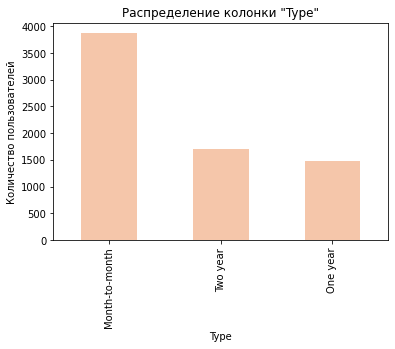

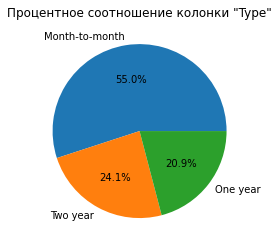

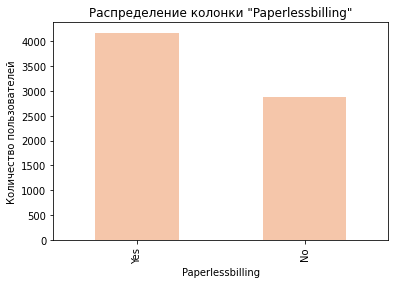

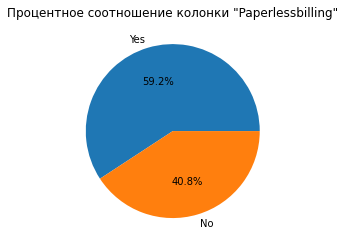

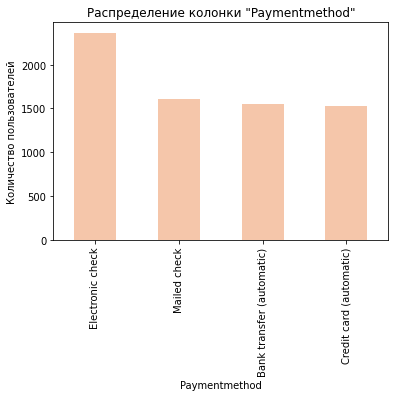

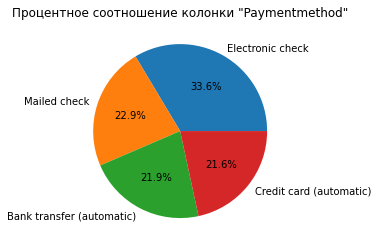

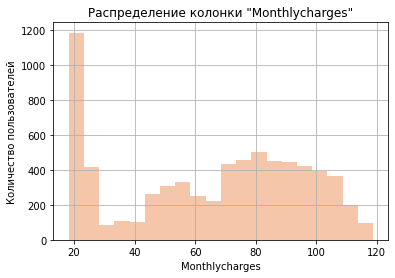

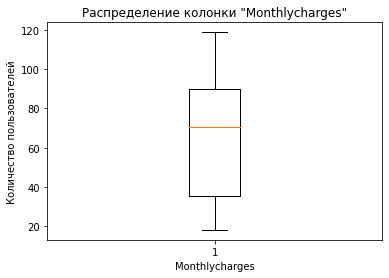

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


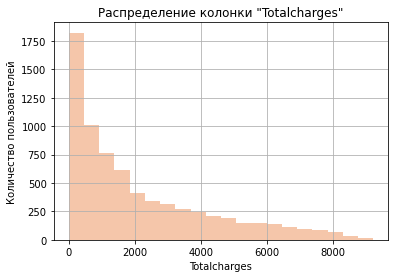

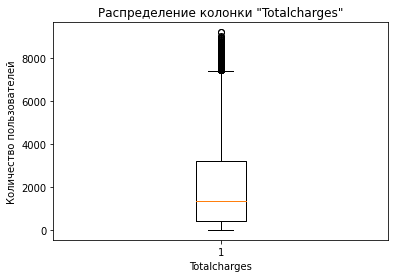

count    7043.000000
mean     2115.312885
std      2112.742814
min         0.000000
25%       436.750000
50%      1343.350000
75%      3236.690000
max      9221.380000
Name: TotalCharges, dtype: float64


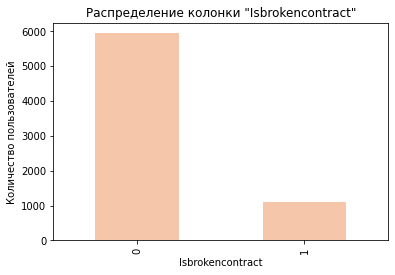

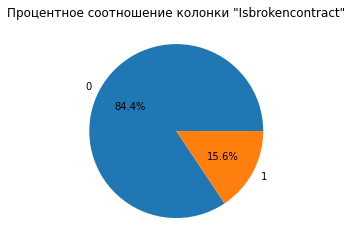

In [33]:
for column in contract.drop('customerID', axis=1).columns:
    analyze_distribution(contract, column)


- **Временной охват:** договоры в данных стартуют с 2013‑10‑01 и фиксируются до 2020‑02‑01. Даты завершения (EndDate) лежат в диапазоне 2014‑06‑01 — 2020‑01‑01 — то есть выборка покрывает несколько лет истории клиентов.

- **Тип договора:** доминирует ежемесячная оплата (Month-to-month) — около 55% клиентов. Долгосрочные контракты встречаются реже: Two year ~24.1%, One year ~20.9%. Это говорит о том, что основная масса клиентов предпочитает более гибкие условия.

- **Электронный расчётный лист:** большинство клиентов пользуются электронными счетами — ~59.2%, против ~40.8% без электронного биллинга. Значит, цифровые каналы для компании важны и уже широко приняты.

- **Способ оплаты:** самый популярный вариант — Electronic check (~33.6%). Остальные способы распределены относительно равномерно: Mailed check (22.9%), Bank transfer (automatic) (21.9%), Credit card (automatic) (21.6%).

**Месячные расходы (MonthlyCharges):**
  - наблюдения: 7043;
  - среднее: ~64.76, медиана: ~70.35;
  - диапазон: 18.25 — 118.75;
  - половина клиентов платит примерно в интервале 35.5 — 89.85 (межквартильный размах).  
    Распределение неоднородное (есть группы с низкими и высокими платежами), что может отражать разные услуги (интернет и телефония).

**Общие расходы (TotalCharges):**
  - среднее: ~2115.31, медиана: ~1343.35;
  - диапазон: 0 — 9221.38;
  - распределение сильно скошено вправо и содержит заметное число выбросов (клиенты с очень большими суммарными расходами). 

### Исследовательский анализ датасета 'personal'

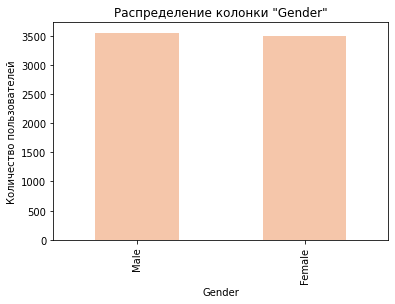

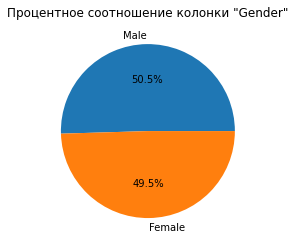

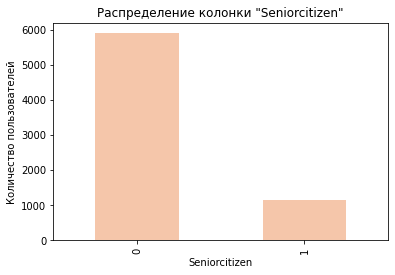

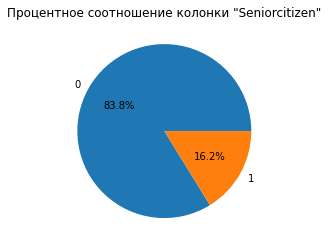

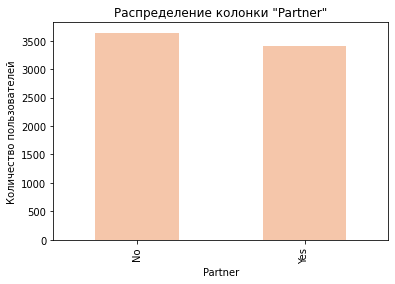

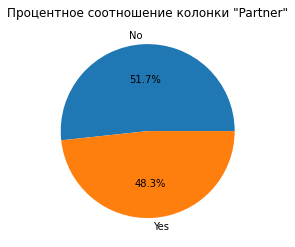

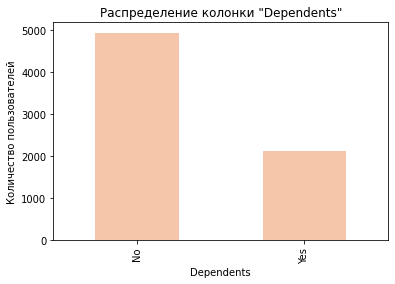

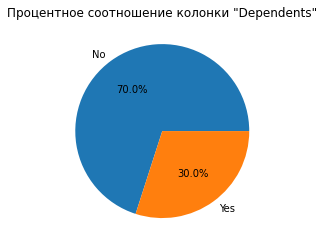

In [34]:
for column in personal.drop('customerID', axis=1).columns:
    analyze_distribution(personal, column)

- **Пол:** распределение пола в выборке практически равномерное — Male ~50.5%, Female ~49.5%. Это означает, что по полу нет перекоса, и признак можно использовать в анализе без опасений, что он представлен слишком малой группой.

- **Достижение пенсионного возраста:** большинство клиентов не являются пожилыми — 0: ~83.8%, тогда как доля пожилых клиентов 1: ~16.2%. Признак заметно несбалансирован, но группа 16% достаточно крупная, чтобы отдельно проверить, отличается ли у неё поведение (например, вероятность расторжения).

- **Семейное положение:** доли клиентов с партнёром и без партнёра близки, но небольшое преимущество у группы без партнёра  No ~51.7%, Yes ~48.3%. Признак выглядит умеренно информативным: в дальнейшем можно проверить гипотезу, что клиенты с партнёром чаще дольше остаются на услуге из‑за более стабильного домохозяйства.

- **Наличие иждивенцев:** большинство клиентов без иждивенцев — No ~70%, при этом Yes ~30%. Признак имеет заметный перекос в сторону “No”, что может отражать структуру клиентской базы. Потенциально наличие иждивенцев может быть связано с более стабильным потреблением услуг и иным тарифным поведением, поэтому его стоит учитывать при анализе оттока и платежей.

### Исследовательский анализ датасета 'internet'

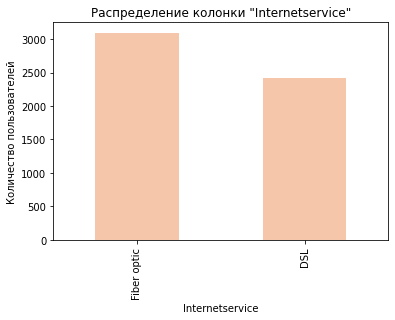

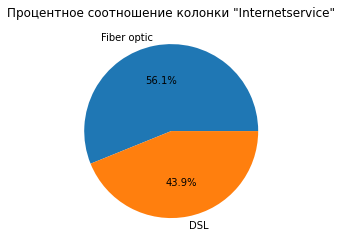

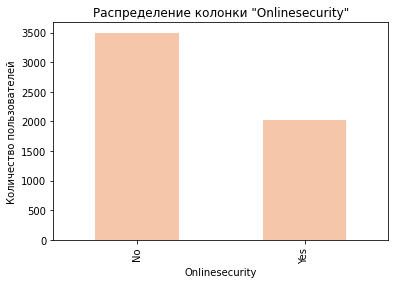

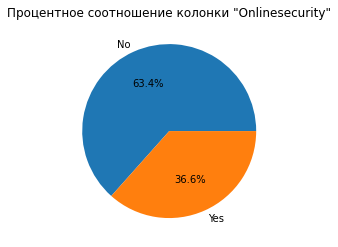

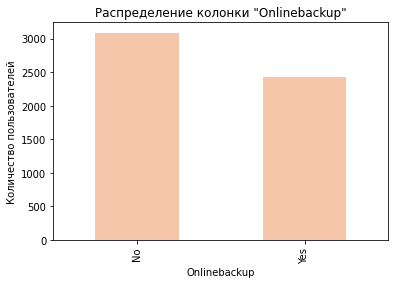

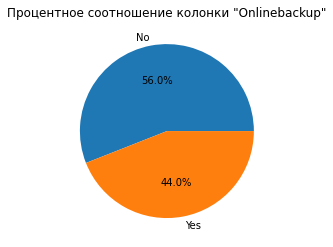

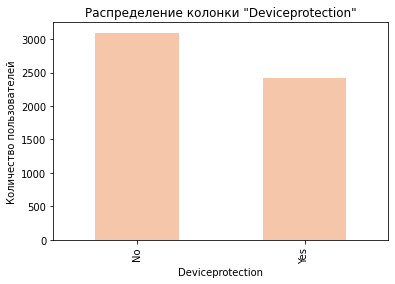

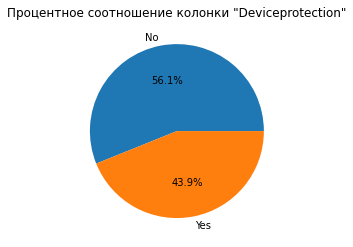

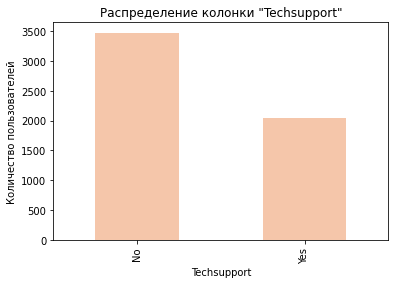

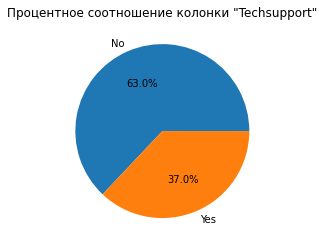

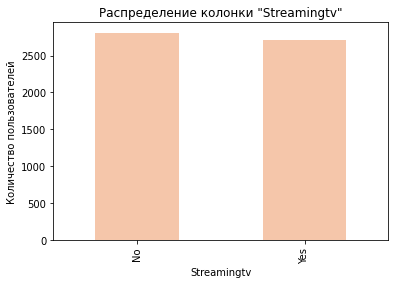

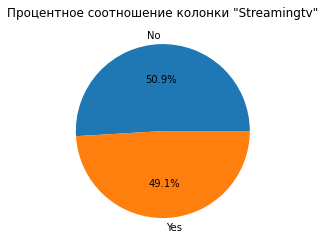

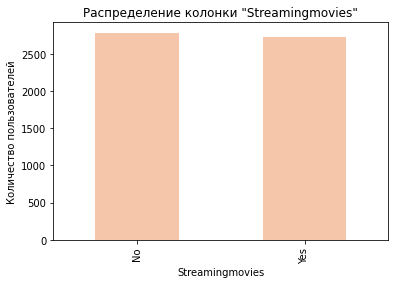

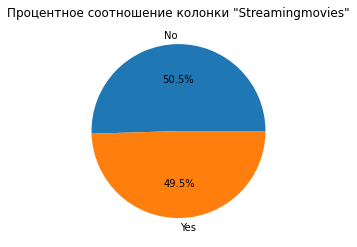

In [35]:
for column in internet.drop('customerID', axis=1).columns:
    analyze_distribution(internet, column)

- **Тип подключения:** в выборке преобладает Fiber optic — около 56.1%, DSL составляет примерно 43.9%. То есть оптоволокно встречается чаще, но распределение в целом достаточно близкое, без сильного перекоса.

- **Блокировка опасных сайтов:** услугу подключили заметно реже, чем отказались от неё — No ~63.4%, Yes ~36.6%. Это указывает, что доп. защита у большинства не подключена (возможно, из‑за цены или низкой ценности в глазах клиентов).

- **Облачное резервное копирование:** распределение ближе к балансу, но всё же чаще услуга не подключена — No ~56.0%, Yes ~44.0%. Значит, резервное копирование пользуется спросом у существенной доли клиентов.

- **Aнтивирус/защита устройств:** картина похожа на OnlineBackup — No ~56.1%, Yes ~43.9%. Дополнительная защита популярна, но всё-таки меньшинство клиентов её покупает.

- **Выделенная техподдержка:** услуга подключена сравнительно редко — Yes ~37.0%, тогда как No ~63.0%. Вероятно, большинство клиентов либо не видит необходимости, либо не хочет доплачивать за поддержку.

- **Cтриминговое ТВ:** почти идеальный баланс — No ~50.9%, Yes ~49.1%. Это говорит о том, что услуга массовая и востребована примерно у половины клиентской базы.

- **Каталог фильмов:** также почти 50/50 — No ~50.5%, Yes ~49.5%. Потребление видеосервисов в целом широко распространено и примерно у половины клиентов включено в пакет/подключено отдельно.

Общий итог по блоку интернет‑услуг: “развлекательные” сервисы (StreamingTV/Movies) подключены примерно у половины клиентов, а “защитные/сервисные” (OnlineSecurity, TechSupport) заметно реже — около 1/3, что может отражать чувствительность к цене или недостаточную воспринимаемую ценность этих опций.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Исследовательский анализ датасета 'phone'

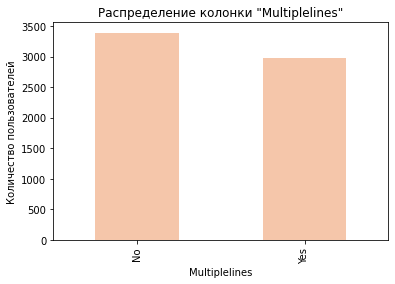

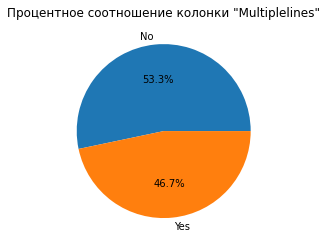

In [36]:
for column in phone.drop('customerID', axis=1).columns:
    analyze_distribution(phone, column)

Распределение почти равномерное, признак можно использовать для сравнения между группами.

### Вывод по исследовательскому анализу

Данные описывают клиентов и их договоры за 2013–2020 гг.; целевой признак IsBrokenContract несбалансирован (≈15.6% оттока), что вполне ожидаемо. Есть сильные “поведенческие” и продуктовые признаки (тип договора, платежи, подключенные услуги) — они обычно наиболее полезны для прогноза оттока. Часть признаков — идентификаторы или дублирующая/потенциально “подсматривающая” информация — их лучше исключать из обучения.

 Признаки, которые полезны и стоит оставить
1) **Договор и платежное поведение**
- Type — отражает уровень “привязки” (month-to-month потенциально может быть связан с оттоком).
- PaymentMethod — различает автоплатежи/ручные оплаты, ручные оплаты могут чаще сопровождаться оттоком.
- PaperlessBilling — связан с двумя предыдущими признаками.
- MonthlyCharges — показатель текущей стоимости тарифа; полезно посмотреть связь дороговизны тарифа и оттока.
- TotalCharges — показывает длительность отношений пользователя и компании и общую ценность клиента. 

2) **Продуктовые услуги (интернет/сервисы)**
- InternetService — тип подключения может быть связан и с ценой, и с качеством, и с оттоком.
- OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport — доп. услуги; помогают отличать клиентов с “пакетной” подпиской/высокой вовлеченностью, эти услуги пользуются меньшей популярностью, чем развлекательные услуги, интересно посмотреть связь их наличия с оттоком
- StreamingTV, StreamingMovies — более популярные услуги среди пользователей, могут так же влиять на отток.
- MultipleLines — характеристика набора услуг по телефонии; может быть полезной.

3) **Соц-демо признаки**
- SeniorCitizen — может давать устойчивые различия по поведению.
- Partner, Dependents — признаки домохозяйства; могут быть полезны в комбинациях.
- Gender — распределение по полу практически равномерное, признак потенциально может быть не важен, но убирать сразу его не стоит, лучше посмотреть корреляционный аналих 

**Признаки, которые лучше удалить / не использовать в модели**
- customerID — идентификатор; не несёт смысла для прогноза, может приводить к переобучению.
- EndDate — по факту используется для построения IsBrokenContract (если EndDate заполнен датой, значит контракт завершён). Это утечка таргета: модель будет “угадывать” отток по прямому следу события.
- BeginDate — нет смысла использовать в сыром виде, лучше создать новый признак - длительность

## Объединение данных

### Объединение данных и создание нового признака

In [37]:
# помещаем в main датафрейм contract
main = contract

In [38]:
# создадим список с названиями оставшихся датафреймов
datas = [personal, internet, phone]

In [39]:
# присоединяем каждый датафрейм в main слева, чтобы сохранить всех пользователей
for data in datas:
    main = main.merge(data, on='customerID', how='left')

In [40]:
# выводим получившийся датафрейм
main.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,IsBrokenContract,gender,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0,Female,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,0,Male,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0,Male,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,0,Male,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0,Female,...,No,No,Fiber optic,No,No,No,No,No,No,No


In [41]:
# прверим информацию о датафрейме после объединения
main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1101 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   IsBrokenContract  7043 non-null   int64         
 9   gender            7043 non-null   object        
 10  SeniorCitizen     7043 non-null   int64         
 11  Partner           7043 non-null   object        
 12  Dependents        7043 non-null   object        
 13  InternetService   5517 non-null   object        
 14  OnlineSecurity    5517 n

Все данные на месте, ожидаемо образовались пропуски в столбцах о наличии услуг, так как не все пользователи пользуются всеми услугами. Типа данных сохранились верно, осталось удалить лишние столбцы и создать новый признак: длительность договора

In [42]:
# поместим колонку customerID в индекс 
main = main.set_index('customerID')

In [43]:
current_date = pd.to_datetime('2020-02-01')

In [44]:
# введем новый признак 'ContractDuration' - длительность договора
main['ContractDuration'] = np.where(
    main['EndDate'].notna(),
    main['EndDate'] - main['BeginDate'], 
    current_date - main['BeginDate'])

In [45]:
# изменим тип данных в новом признаке на int
main['ContractDuration'] = (main['ContractDuration'].dt.total_seconds() // 86400).astype('float')

In [46]:
main.head(10)

,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,IsBrokenContract,gender,SeniorCitizen,...,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,ContractDuration
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0,Female,0,...,No,DSL,No,Yes,No,No,No,No,NaN,31.0
5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,0,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,1036.0
3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,123.0
7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,0,Male,0,...,No,DSL,Yes,No,Yes,Yes,No,No,NaN,1371.0
9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,153.0
9305-CDSKC,2019-03-01,NaT,Month-to-month,Yes,Electronic check,99.65,1150.96,0,Female,0,...,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes,337.0
1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,0,Male,0,...,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes,671.0
6713-OKOMC,2019-04-01,NaT,Month-to-month,No,Mailed check,29.75,300.48,0,Female,0,...,No,DSL,Yes,No,No,No,No,No,NaN,306.0
7892-POOKP,2017-07-01,NaT,Month-to-month,Yes,Electronic check,104.80,3573.68,0,Female,0,...,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Yes,945.0


In [47]:
# удалим столбец EndDate и BeginDate
main = main.drop(['EndDate', 'BeginDate'], axis=1)

In [48]:
# проверим информацию о датафрейме после удаления столбцов и создания нового признака
main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   object 
 1   PaperlessBilling  7043 non-null   object 
 2   PaymentMethod     7043 non-null   object 
 3   MonthlyCharges    7043 non-null   float64
 4   TotalCharges      7043 non-null   float64
 5   IsBrokenContract  7043 non-null   int64  
 6   gender            7043 non-null   object 
 7   SeniorCitizen     7043 non-null   int64  
 8   Partner           7043 non-null   object 
 9   Dependents        7043 non-null   object 
 10  InternetService   5517 non-null   object 
 11  OnlineSecurity    5517 non-null   object 
 12  OnlineBackup      5517 non-null   object 
 13  DeviceProtection  5517 non-null   object 
 14  TechSupport       5517 non-null   object 
 15  StreamingTV       5517 non-null   object 
 16  StreamingMovies   5517 non-null 

### Обработка пропусков в новом датафрейме

Пропуски в столбцах, содержащих интернет услуги, сигнализируют о том, что пользователь не пользуются интернетом, а пропуски в столбце 'MultipleLines' - о том, что пользователь не пользуется телефонией. Отсюда вывод, что пропусков одновременно в столбцах с интернетом и в столбце с телефонией быть не может. Проверим этот факт

In [49]:
# проверяем пропуски в любом столбце интернета и столбце 'MultipleLines'
((main['OnlineSecurity'].isna()) & (main['MultipleLines'].isna())).sum()

0

Действительно, нет пользователей, которые бы не пользовались одновременно и интернетом, и связью. Тогда пропуски в колонках, содержащих услуги интернета, можно заполнить как "No internet service", в колонке про связь как "No phone service"

In [50]:
internet_columns = internet.drop('customerID', axis=1).columns

In [51]:
internet_columns

Index(['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')

In [52]:
# заполняем пропуски в колонках с интернет-услугами
main[internet_columns] = main[internet_columns].fillna('No internet service')

In [53]:
# заполняем пропуски в колонке с услугой телефонии
main['MultipleLines'] = main['MultipleLines'].fillna('No phone service')

In [54]:
main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   object 
 1   PaperlessBilling  7043 non-null   object 
 2   PaymentMethod     7043 non-null   object 
 3   MonthlyCharges    7043 non-null   float64
 4   TotalCharges      7043 non-null   float64
 5   IsBrokenContract  7043 non-null   int64  
 6   gender            7043 non-null   object 
 7   SeniorCitizen     7043 non-null   int64  
 8   Partner           7043 non-null   object 
 9   Dependents        7043 non-null   object 
 10  InternetService   7043 non-null   object 
 11  OnlineSecurity    7043 non-null   object 
 12  OnlineBackup      7043 non-null   object 
 13  DeviceProtection  7043 non-null   object 
 14  TechSupport       7043 non-null   object 
 15  StreamingTV       7043 non-null   object 
 16  StreamingMovies   7043 non-null 

### Вывод: 

В данном шаге объединила данные по ключу 'customerID', который впоследствии перенесла в индекс. Создала новый признак 'ContractDuration' - длительность договора. Удалила признаки 'BeginDate' (не несет сам по себе важной информации) и 'EndDate' (вызовет утечку данных). 

Заполнила образовавшиеся пропуски в объединенном датасете: пропуски в столбцах с той или иной услугой свидетельствуют о том, что пользователь не пользуется интернетом/связью, поэтому пропуски в интернет-услугах были заполнены как 'No internet service', а в колонке с услугой телефонии - как 'No phone service'. 

## Исследовательский анализ данных объединенного датафрейма

### Исследовательский анализ данных

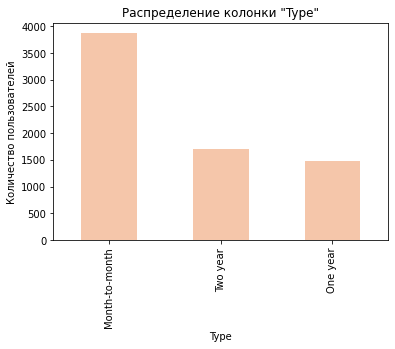

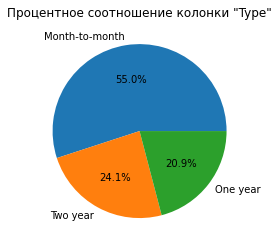

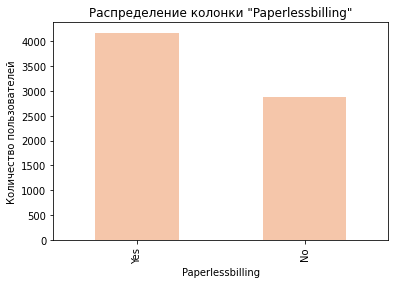

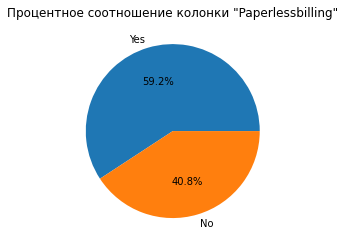

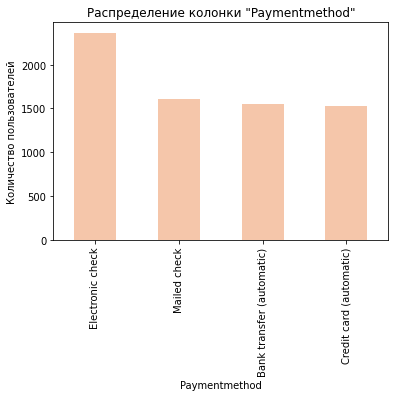

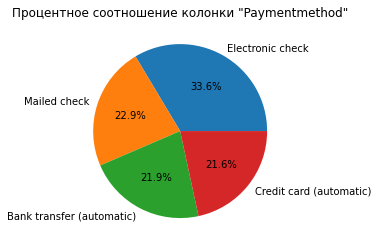

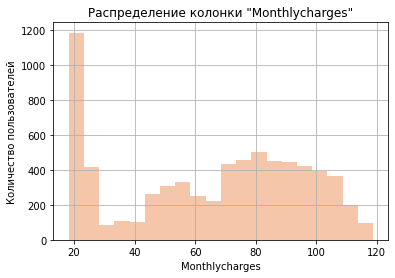

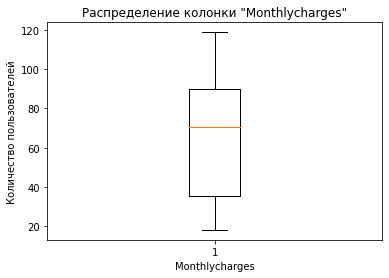

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


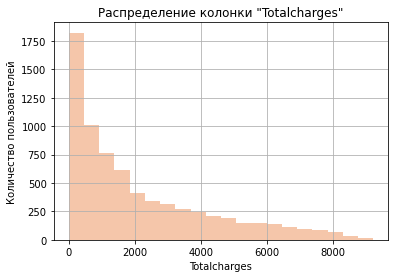

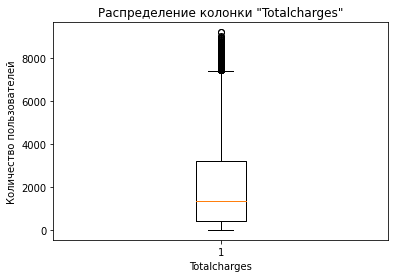

count    7043.000000
mean     2115.312885
std      2112.742814
min         0.000000
25%       436.750000
50%      1343.350000
75%      3236.690000
max      9221.380000
Name: TotalCharges, dtype: float64


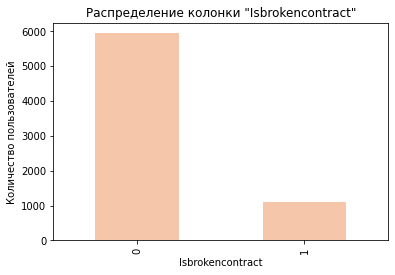

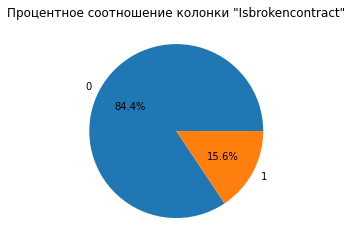

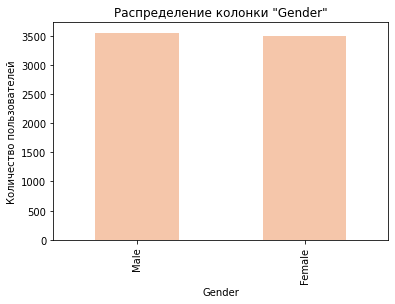

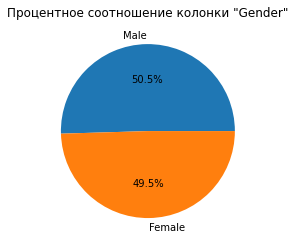

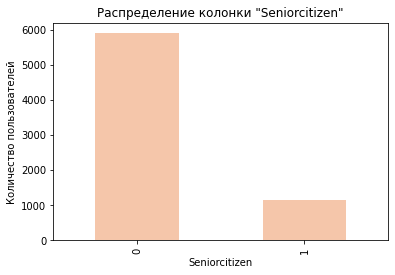

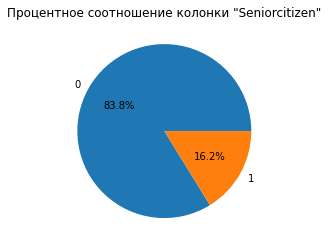

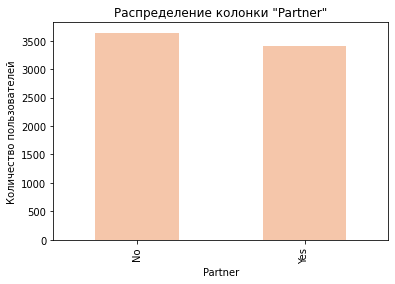

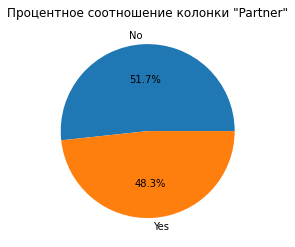

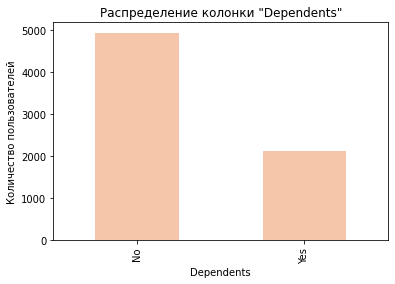

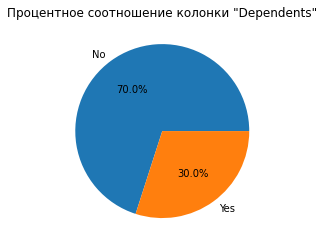

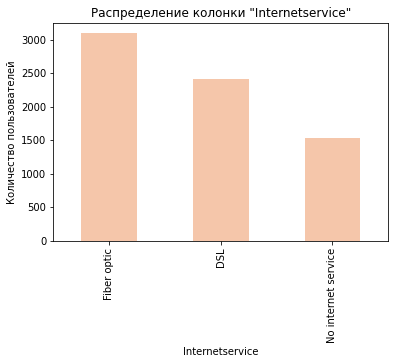

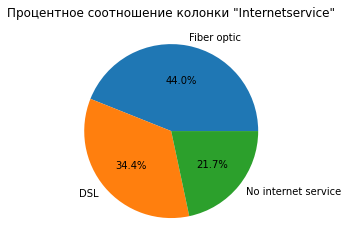

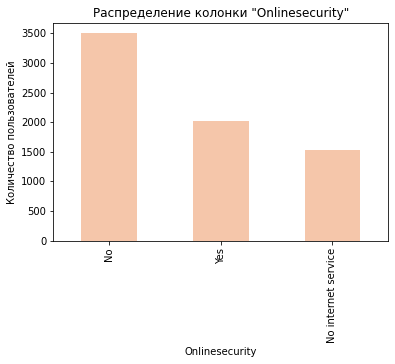

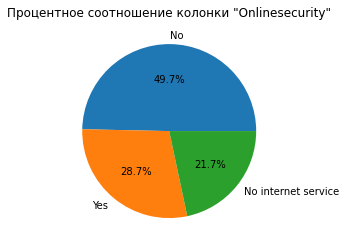

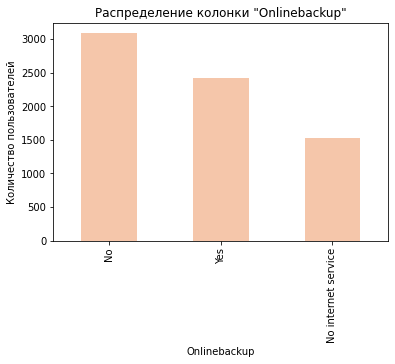

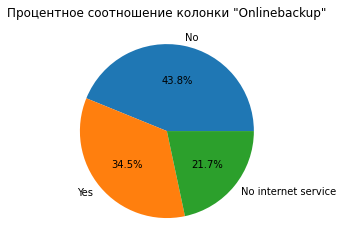

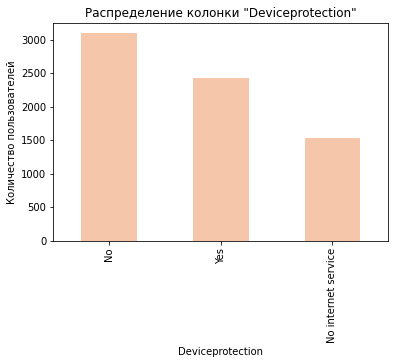

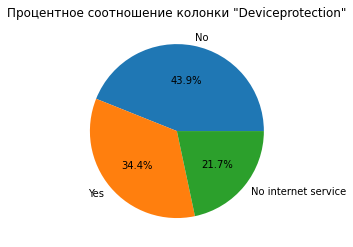

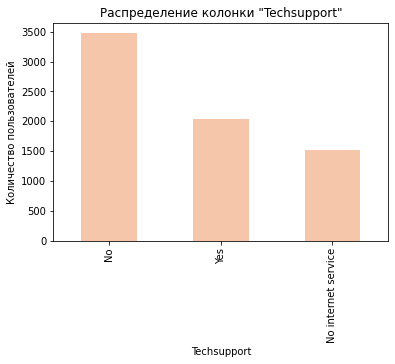

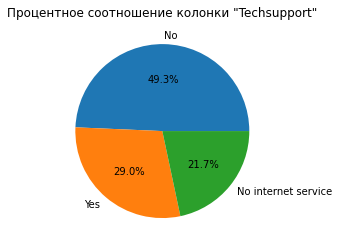

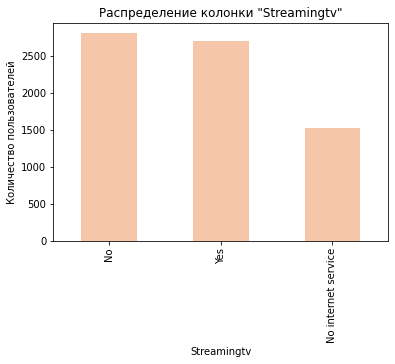

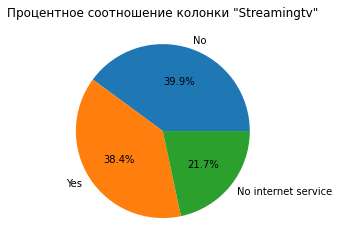

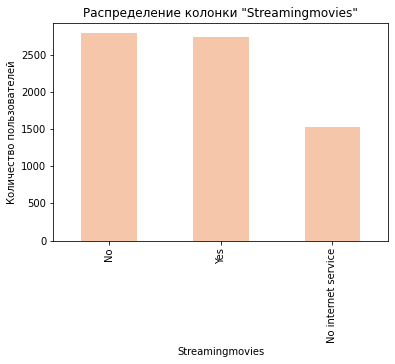

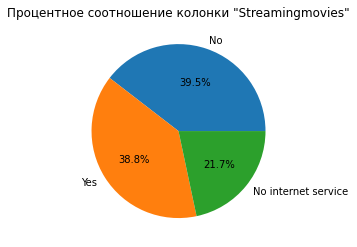

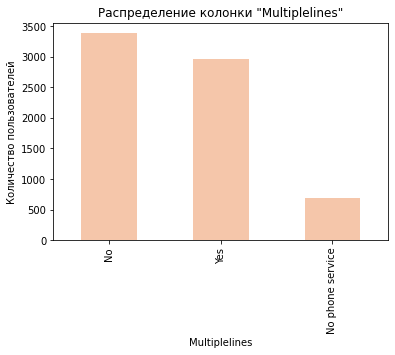

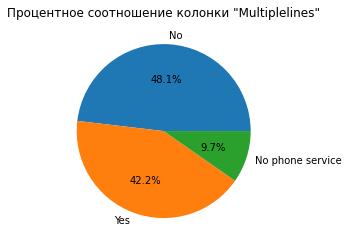

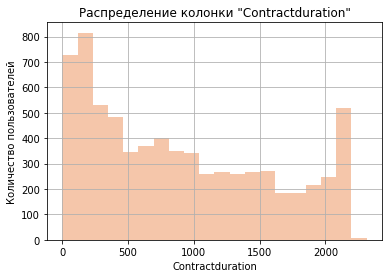

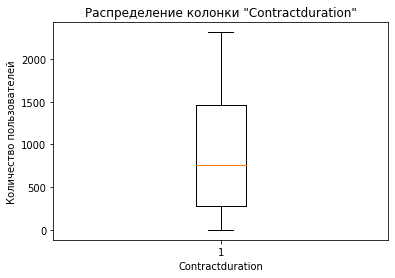

count    7043.000000
mean      898.555729
std       683.130510
min         0.000000
25%       276.000000
50%       761.000000
75%      1461.000000
max      2314.000000
Name: ContractDuration, dtype: float64


In [55]:
# используем функцию для исследотельского анализа данных
for column in main.columns:
    analyze_distribution(main, column)

**Вывод:** Для колонок  'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges','IsBrokenContract', 'Gender', 'SeniorCitizen','Partner', 'Dependents' распределения не поменялись, кратко прорезюмируем их:

В выборке преобладает ежемесячный тип оплаты (около 55%), при этом электронный биллинг используют примерно 59% клиентов, а самый популярный способ платежа — электронный чек (~33.6%). Месячные платежи сильно варьируются (в среднем ~64.8, медиана ~70.35, диапазон 18.25–118.75), а общие расходы имеют правостороннее распределение с выбросами (до ~9221), что отражает заметную разницу в “ценности” клиентов и длительности их обслуживания. Целевой признак IsBrokenContract несбалансирован: расторжения составляют около 15.6%. Большую часть пользователей составляют непожилые (83.8%) люди без иждиценцев (70%), распределение по полу и наличию партнера практически равномерное.

Теперь мы знаем, что 21.7% пользователей не пользуются интернетом и 9.7% пользователей не пользуются связью. 
Распределения интернет-услуг следующее:
- 44% пользователей используют оптоволоконный кабель и 34.4% используют телефонную линию.
- блокировку небезопасных сайтов используют 28.7%, не использует - почти половина, практически такое же распределение у услуги технической поддержки.
- антивирус используют чаще - 34.5%, не используют - 43.8%.
- распределение стримингового телевидения почти равномерно: 38.4% 'да' против 39.9% 'нет'.

Распределение услуги "подключение телефона к нескольким линиям одновременно":
- 42.2% используют, 48.1% - не используют

По распределению нового признака 'ContractDuration' видно, что база состоит из нескольких «когорт»:
- много клиентов со стажем до ~1 года (до 276 дней — 25% базы);
- крупный пласт со стажем ~2 года (медиана 761 день ≈ 2.1 года);
- заметная доля «старых» клиентов 4+ лет (75% = 1461 день ≈ 4 года, максимум ≈ 6.3 года).

Сильная правосторонняя асимметрия говорит о том, коротких контрактов много, а длинные встречаются реже, но не единично. Поэтому среднее (≈2.46 года) хуже описывает «типичного» клиента, чем медиана (≈2.1 года).



Стоит так же рассмотреть распределения признаков для разных классов целевого признака, напишем для этого новую функцию

In [56]:
def analyze_class_distribution(data, column):
    num_columns_data = data.select_dtypes(include='float').columns.to_list()
    # для интервальных колонок делаем визуализацию распределения плотности для класса 0 и 1
    if column in num_columns_data:
        plt.figure(figsize=(8,4))
        sns.histplot(
        data=data, x=column, hue='IsBrokenContract',
        bins=30,
        stat="density",
        common_norm=False,   
        multiple="layer",
        alpha=0.4
        )
        plt.title(f"{column}: плотность по классам")
        plt.show()
    # для категориальных - будем визуализировать доли классов внутри каждой категории   
    else:
        ct = pd.crosstab(data[column], data['IsBrokenContract'], normalize="index")  
        ax = ct.plot(kind="bar", stacked=True, figsize=(8,4))
        ax.set_ylabel("Доля внутри категории")
        ax.set_title(f"{column}: доли классов внутри каждой категории")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

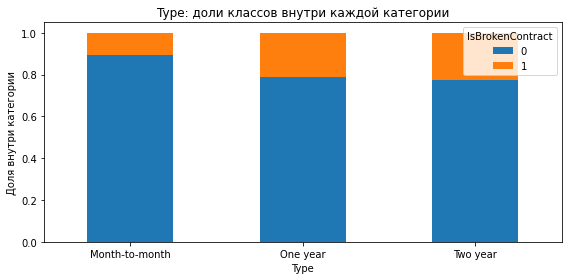

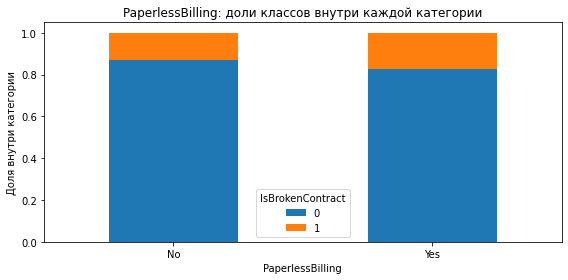

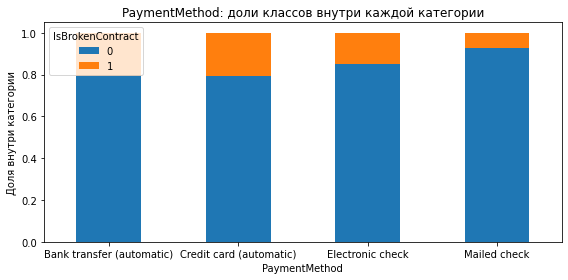

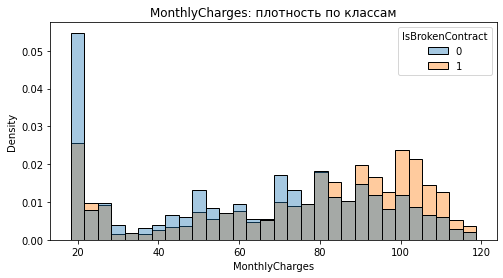

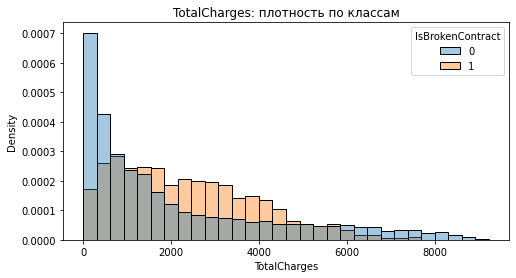

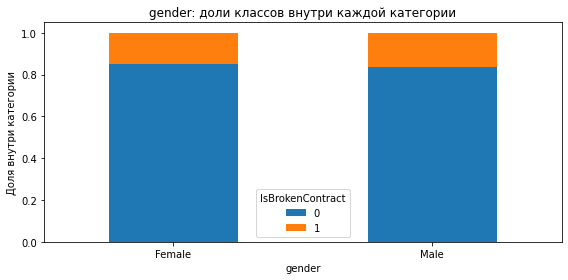

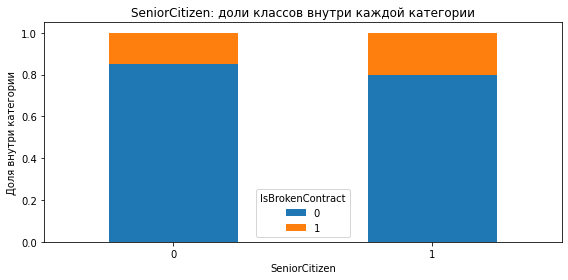

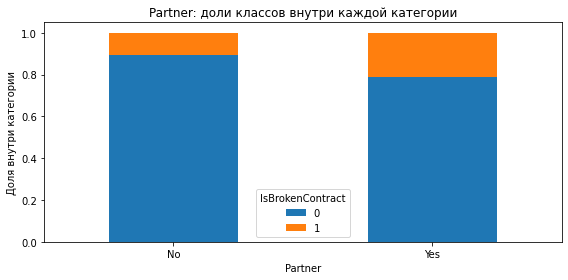

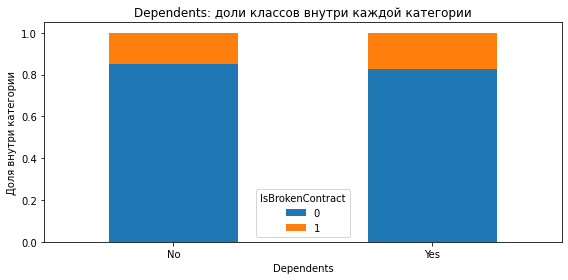

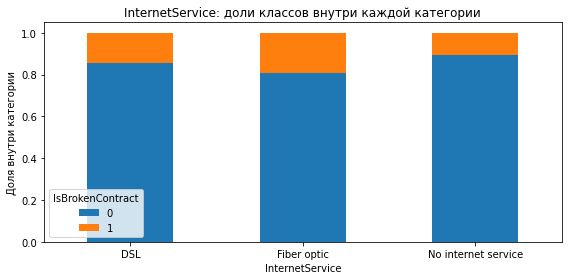

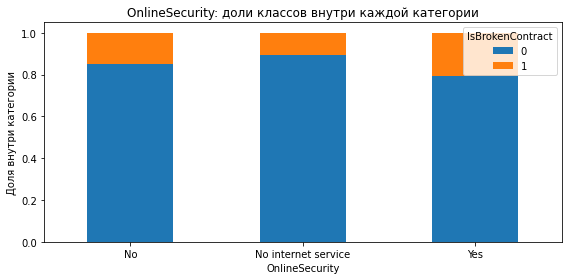

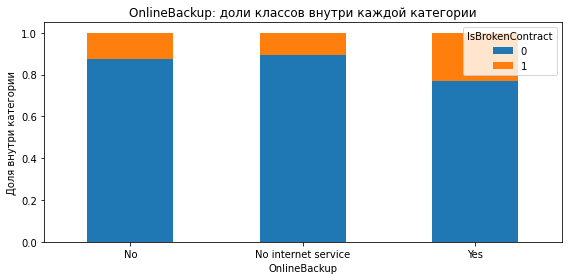

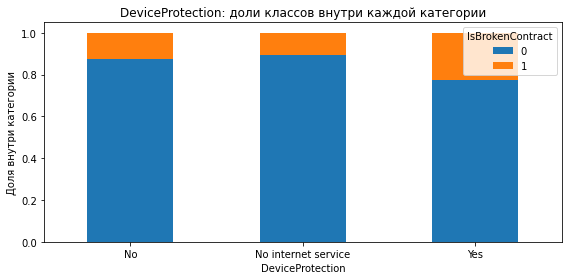

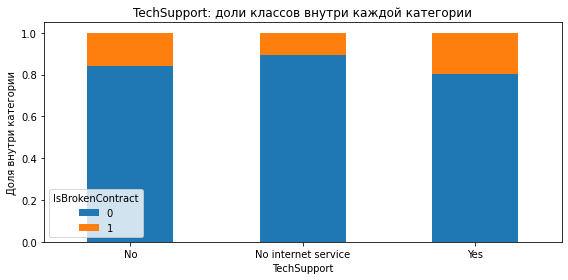

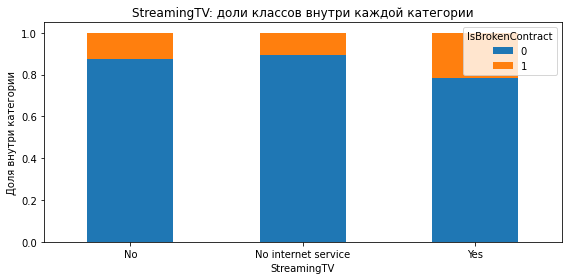

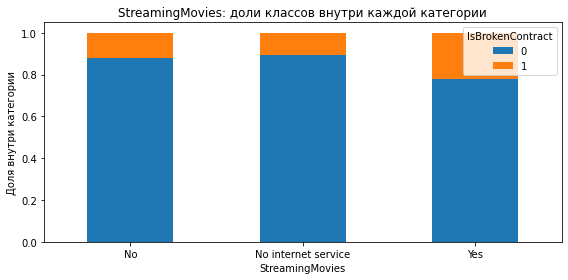

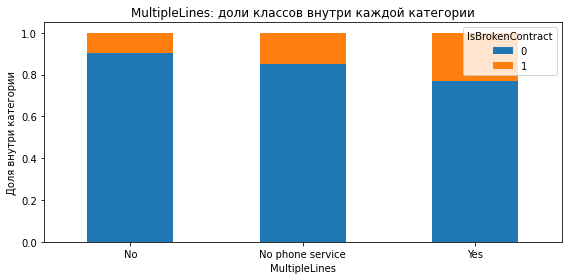

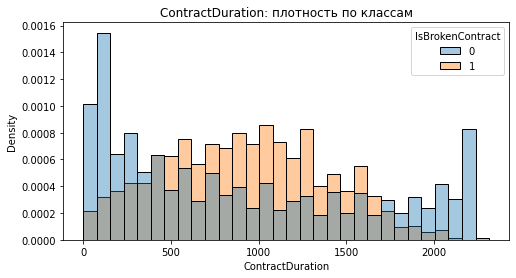

In [57]:
for column in main.drop('IsBrokenContract', axis=1).columns:
    analyze_class_distribution(main, column)

**Вывод:** 
Доли классов внутри каждой категории для категориальных признаков получились следующие:
- Тип контракта: больше всего доля у двухлетнего тарифа - 20%, почти такая же доля у однолетнего тарифа, пользователи, которые оплачивают услуги ежемесячно в 2 раза реже расторгают договор.
- Пользователи, получающие электронный чек, расторгают контракт незначительно чаще (на ~5%).
- Реже всего расторгают контракт пользователи с типом оплаты MailedCheck и ElectronicCheck, пользователи с автоматической оплатой - расторгают чаще.
- Мужчины расторгают контракт чуть чаще, чем женщины.
- Пенсионеры расторгают контракт чаще.
- Пользователи с партнером расторгают контракт почти в 2 раза чаще, чем без.
- Наличие иждивенцев незначительно влияет на расторжение контракта.
- Подключение интернета через оптоволоконный кабель примерно на 5-7% чаще связано с расторжением контракта.
- Все остальные интернет-услуги и телефонии увеличивают шанс расторжения, это может быть связано с неудовлетворенностью сервисами 

Глядя на распределения плотности интервальных признаков можно сделать следующие выводы:
- Чем выше ежемесячный платеж, тем выше вероятность расторжения контракта.
- Вероятность расторгнуть договор больше у пользователей с общими расходами от 2000 до 4000, после 4000 вероятность сильно снижается и достигает 0 для пользователей с расходами выше 8000 - это касается максимально лояльных пользователей.
- Для длительности контракта самой рискованной группой являются пользователи, пользующиеся услугами от 1,5 до 4 лет, после чего она маловероятна.

### Корреляционный анализ

In [58]:
# создадим список с интервальными колонками
interval_cols = [
    'MonthlyCharges',
    'TotalCharges',
    'ContractDuration'
]

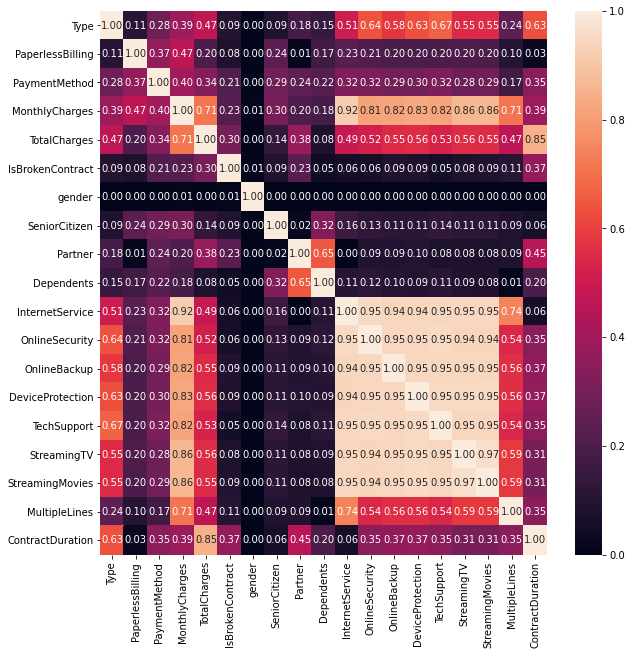

In [59]:
# построим phik-матрицу
plt.figure(figsize=(10, 10))
sns.heatmap(main.phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f')
plt.show()

Задача корреляционного анализа: избавиться от мультиколлинеарных признаков(>0.9) и признаков, которые имеют крайне низкую корреляцию с целевым признаком (<0.05). 

Корреляцию ниже порогового значения имеет признак 'gender' (пол), стоит его убрать.

Мультиколлинеарность наблюдается между всеми интернет-услугами и между признаками 'MonthlyCharges' и 'InternetService'. Сильная корреляция между ежемесячными тратами и другими интернет-услугами тоже наблюдается, но она ниже порогового уровня и может не так сильно сказать. 
Из интернет-услуг нужно оставить только 1 услугу, которая имеет наибольшую корреляцию с целевым признаком и наименьшую - с другими признаками. Это колонка 'OnlineBackup'

Однако, чтобы учесть наличие других интернет-услуг, есть смысл создать признак 'NumInternetServices' 

In [60]:
main = main.drop('gender', axis=1)

In [61]:
main['NumInternetServices'] = (main[internet_columns] == 'Yes').sum(axis=1)

In [62]:
internet_columns = internet_columns.drop('OnlineBackup')

In [63]:
main = main.drop(internet_columns, axis=1)

In [64]:
interval_cols.append('NumInternetServices')

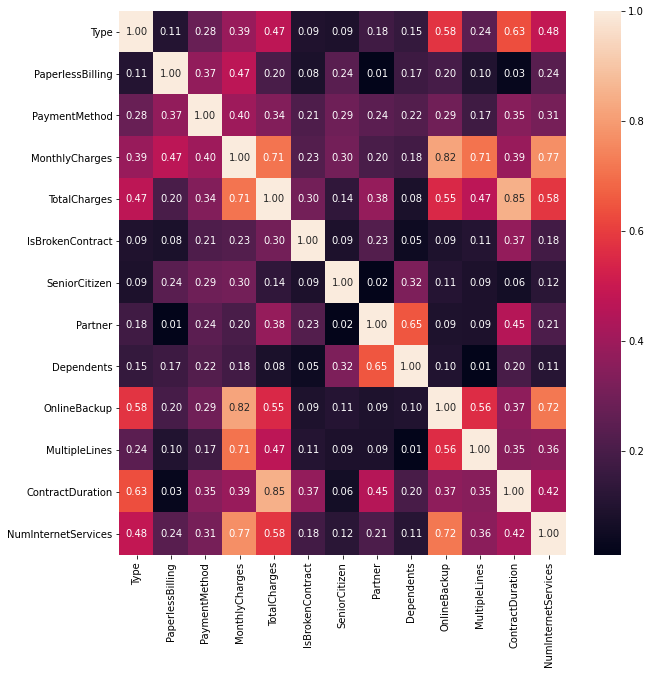

In [65]:
# построим phik-матрицу
plt.figure(figsize=(10, 10))
sns.heatmap(main.phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f')
plt.show()

Новый признак имеет значительную корреляцию с целевым (0.18) и при этом не мультиколлинеарен с другими признаками, что делает его добавление целесообразным.  

### Общий вывод по исследовательскую и корреляционному анализу данных

- База и платежи: преобладает помесячный контракт (~55%); paperless billing у 59%; самый частый метод оплаты — Electronic check (33.6%). IsBrokenContract несбалансирован: расторжения 15.6%.
- Демография: большинство клиентов — непожилые (83.8%) и без иждивенцев (70%); пол и наличие партнёра близки к равномерным.
- Деньги и “ценность” клиентов: MonthlyCharges сильно варьирует (ср. ~64.8; медиана ~70.35; 18.25–118.75). TotalCharges имеет правостороннюю асимметрию и выбросы (до ~9221), что отражает сильную разницу по сроку жизни/объёму платежей.
- Услуги: 21.7% без интернета и 9.7% без телефонии. Среди интернет-подключений лидирует оптоволокно (~44%), далее DSL (~34.4%). Доп. интернет‑услуги (backup/antivirus/support/parental control/streaming и т.п.) распределены близко к “да/нет” с перевесом в сторону “не используют” у ряда опций.
- Стаж (ContractDuration): база состоит из нескольких когорт: много клиентов до ~1 года (25% до 276 дней), крупная когорта ~2 года (медиана 761 день ≈ 2.1 года), заметная доля 4+ лет (75% = 1461 день ≈ 4 года, максимум ≈ 6.3). Из‑за асимметрии медиана лучше описывает “типичного” клиента, чем среднее.

Различия между классами (что связано с расторжением):
- Чем короче контракт/помесячная оплата, тем выше риск; двухлетние/годовые тарифы более устойчивые, помесячные — примерно в 2 раза реже у расторгающих (т.е. сильнее ассоциированы с churn).
- Electronic check связан с немного более высокой долей расторжений (~+5%).
- Мужчины расторгают чуть чаще; пенсионеры — заметно чаще.
- Partner в ваших расчетах связан с более высокой долей расторжения (почти в 2 раза), Dependents влияет слабо.
- Оптоволокно ассоциировано с оттоком чаще (~+5–7%); в целом наличие/подключение доп. услуг интернета/телефонии повышает риск (возможная прокси‑метрика неудовлетворенности/сложности сервиса).
- По непрерывным признакам: чем выше MonthlyCharges — тем выше риск; по TotalCharges риск выше в зоне ~2000–4000 и резко падает после 4000 (практически 0 при >8000 — наиболее лояльные/долго живущие). По длительности контракта риск выше примерно в интервале 1.5–4 года, после чего становится маловероятным.

Корреляционный анализ (отбор признаков):
- По порогу низкой связи с целевым (<0.05) удаляем gender.
- Обнаружена мультиколлинеарность: между интернет‑услугами (взаимосвязаны) и между MonthlyCharges и InternetService. Чтобы снизить избыточность, из интернет‑услуг оставляем одну наиболее “информативную” и наименее зависимую — OnlineBackup.
- Чтобы не терять информацию о “насыщенности” услуг, добавляем агрегат NumInternetServices: он заметно коррелирует с целевым (~0.18) и не создает сильной мультиколлинеарности, поэтому его включение оправдано.

## Подготовка данных

In [66]:
# зададим значения
RANDOM_STATE = 120626
TEST_SIZE = 0.25

In [83]:
main['NumInternetServices'] = main['NumInternetServices'] .astype('float')

In [84]:
# разделим данные на тестовую и тренировочную выборки
X_train, X_test, y_train, y_test = train_test_split(
    main.drop('IsBrokenContract', axis=1),
    main['IsBrokenContract'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify=main['IsBrokenContract']
)

In [85]:
# разобьем колонки датафрейма по методу обработки
num_columns = X_train.select_dtypes(include='float').columns.to_list()

In [87]:
ohe_columns = X_train.drop(num_columns, axis=1).columns.to_list()

In [88]:
ohe_columns

['Type',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'OnlineBackup',
 'MultipleLines']

<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> Почему лучше? Это делает тариф дороже и ее подключение могли навязать. Мы не знаем, то есть не можем достоверно оценить
</div>

In [89]:
data_preprocessor = ColumnTransformer(
    [('ohe', OneHotEncoder(drop='first', handle_unknown='error'), ohe_columns),
     ('num', StandardScaler(), num_columns)
    ]
)

**Вывод:** В данном шаге я создала пайплайн для подготовки данных с учетом особенностей признаков:  с помощью скейлера будут масштабироваться данные типа float ('MonthlyCharges', 'TotalCharges', 'ContractDuration'), остальные признаки закодируем обычным One-hot Encoding

## Обучение моделей машинного обучения

В данном проекте обучим 4 модели: 2 простых - логистическая регрессия и дерево решений и 2 градиентного спуска - CatBoost и LGBM. Обучать модели будем отдельно для того, чтобы проще было найти ошибки и исправить их. Создадим вспомогательную функцию find_the_best внутри которой будет происходит рандомизированный поиск лучшей модели 

In [90]:
# создадим функцию для вывода лучшей модели и значения метрики
def find_the_best(pipe, param_grid):
    _cv = KFold(n_splits=5, shuffle=True, random_state=42)
    randomized_search = RandomizedSearchCV(
    pipe,
    param_grid,
    cv=_cv,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
    )
    randomized_search.fit(X_train, y_train)
    best_model = randomized_search.best_estimator_
    best_score = randomized_search.best_score_
    return {'pipe': randomized_search,
            'model': best_model, 
            'score': best_score,
            'params': randomized_search.best_params_}
        

### Логистическая регрессия

In [91]:
# создадим пайплайн для логистической регрессии
pipe_logreg = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model',  LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

В качестве гиперпараметров рассмотрим коэффициент регуляризации C и максимальное количество итераций, а так же подберем наилучший способ масштабирования для числовых признаков

In [92]:
# список параметров для логистической регрессии
param_grid_logreg =  {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__max_iter': [5000, 20000],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()]
    
}

In [93]:
res_logreg_1 = find_the_best(pipe_logreg, param_grid_logreg)

In [94]:
res_logreg_1['score']

0.7550078523588444

In [95]:
res_logreg_1['params']

{'preprocessor__num': StandardScaler(),
 'model__max_iter': 20000,
 'model__C': 1}

Стоит рассмотреть диапазоны гиперпараметров шире, чтобы не упустить наилучшую модель

In [96]:
# создаем новый словарь параметров
param_grid_logreg =  {
    'model__C': [0.1, 3],
    'model__max_iter': list(range(20000, 50000)),
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()]
    
}

In [97]:
res_logreg_2 = find_the_best(pipe_logreg, param_grid_logreg)

In [98]:
res_logreg_2['score']

0.754899488559866

In [99]:
res_logreg_2['params']

{'preprocessor__num': RobustScaler(), 'model__max_iter': 38441, 'model__C': 3}

Значение метрики ухудшилось, но незначительно. Вероятно, с первой моделью мы достигли максимума с логистической регрессией, однако это значение не достигает целевого (0.85) 

### Модель DecisionTreeClassifier

In [100]:
# создаем пайплайн для дерева решений
pipe_tree = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model',  DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

In [101]:
# создадим список гиперпараметров 
param_grid_tree = {
    'model__max_depth': list(range(1, 7)),
    'model__min_samples_split': list(range(2, 7)),
    'model__min_samples_leaf': list(range(1, 7)),
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

In [102]:
res_tree = find_the_best(pipe_tree, param_grid_tree)

In [103]:
res_tree['score']

0.7789264134428009

In [104]:
res_tree['params']

{'preprocessor__num': StandardScaler(),
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 4,
 'model__max_depth': 5}

Значения гиперпараметров лучшей модели находятся не на концах диапазона, а значит расширять их не нужно, лучшая метрика получилась - 0.78, что опять не достигает необходимого порога в 0.85

### Модель CatBoost

In [105]:
# создадим пайплайн для категориального бустинга 
pipe_cat = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', CatBoostClassifier(early_stopping_rounds=200, random_seed=RANDOM_STATE, verbose=0)),
])

Для категориального бустинга не требуется масштабирование данных, поэтому введем параметр 'preprocessor__num': ['passthrough'], чтобы не тратить время на перебор

In [106]:
# создадим список гиперпараметров для категориального бустинга
param_grid_cat = {
    'model__iterations': [500, 1500, 3000],
    'model__learning_rate': [0.03, 0.07, 0.1],
    'model__depth': [4, 6, 8],
    'preprocessor__num': ['passthrough']
}

In [107]:
res_cat_1 = find_the_best(pipe_cat, param_grid_cat)

In [108]:
res_cat_1['score']

0.9158663611304432

In [109]:
res_cat_1['params']

{'preprocessor__num': 'passthrough',
 'model__learning_rate': 0.07,
 'model__iterations': 3000,
 'model__depth': 4}

In [110]:
param_grid_cat = {
    'model__iterations': range(1000, 2000, 100),
    'model__learning_rate': np.linspace(0.05, 1, 10),
    'model__depth': range(3, 7),
}

In [111]:
res_cat_2 = find_the_best(pipe_cat, param_grid_cat)

In [112]:
res_cat_2['score']

0.9103123768483854

In [113]:
res_cat_2['params']

{'model__learning_rate': 0.36666666666666664,
 'model__iterations': 1800,
 'model__depth': 3}

### Модель LGBM

In [114]:
# создадим пайплайн для lgbm модели
pipe_lgbm = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', LGBMClassifier(random_state=RANDOM_STATE)),
])

LGBM модель так же, как и категориальный бустинг не нуждается в масштабировании

In [115]:
# создадим список гиперпараметров для LGBM
param_grid_lgbm = {
    'model__n_estimators': [300, 800, 1500],
    'model__learning_rate': [0.03, 0.07, 0.1],
    'model__num_leaves': [31, 63, 127],
    'preprocessor__num': ['passthrough']
}

In [116]:
res_lgbm_1 = find_the_best(pipe_lgbm, param_grid_lgbm)

[LightGBM] [Info] Number of positive: 652, number of negative: 3573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 710
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154320 -> initscore=-1.701116
[LightGBM] [Info] Start training from score -1.701116


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 658, number of negative: 3567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 702
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155740 -> initscore=-1.690275
[LightGBM] [Info] Start training from score -1.690275


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 681, number of negative: 3545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 712
[LightGBM] [Info] Number of data points in the train set: 4226, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161145 -> initscore=-1.649731
[LightGBM] [Info] Start training from score -1.649731


...

[LightGBM] [Info] Number of positive: 660, number of negative: 3566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 706
[LightGBM] [Info] Number of data points in the train set: 4226, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156176 -> initscore=-1.686960
[LightGBM] [Info] Start training from score -1.686960


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 653, number of negative: 3573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 703
[LightGBM] [Info] Number of data points in the train set: 4226, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154520 -> initscore=-1.699584
[LightGBM] [Info] Start training from score -1.699584


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 826, number of negative: 4456
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 721
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156380 -> initscore=-1.685412
[LightGBM] [Info] Start training from score -1.685412


In [117]:
res_lgbm_1['score']

0.8810584724210303

In [118]:
res_lgbm_1['params']

{'preprocessor__num': 'passthrough',
 'model__num_leaves': 31,
 'model__n_estimators': 300,
 'model__learning_rate': 0.07}

In [119]:
param_grid_lgbm = {
    'model__n_estimators': range(200, 500, 100),
    'model__learning_rate': np.arange(0.03, 1, 0.01),
    'model__num_leaves': range(20, 40, 5),
    'preprocessor__num': ['passthrough']
}

In [120]:
res_lgbm_2 = find_the_best(pipe_lgbm, param_grid_lgbm)

[LightGBM] [Info] Number of positive: 652, number of negative: 3573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 710
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154320 -> initscore=-1.701116
[LightGBM] [Info] Start training from score -1.701116


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 658, number of negative: 3567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 702
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155740 -> initscore=-1.690275
[LightGBM] [Info] Start training from score -1.690275


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 681, number of negative: 3545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 712
[LightGBM] [Info] Number of data points in the train set: 4226, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161145 -> initscore=-1.649731
[LightGBM] [Info] Start training from score -1.649731


...

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 703
[LightGBM] [Info] Number of data points in the train set: 4226, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154520 -> initscore=-1.699584
[LightGBM] [Info] Start training from score -1.699584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [121]:
res_lgbm_2['score']

0.8860710909346945

In [122]:
res_lgbm_2['params']

{'preprocessor__num': 'passthrough',
 'model__num_leaves': 20,
 'model__n_estimators': 300,
 'model__learning_rate': 0.19000000000000003}

Модель достигла нужного значения, но оно оказалось меньше, чем у категориального бустинга

### Выбор лучшей модели

In [123]:
score_dict = {
    'Логистическая регрессия': res_logreg_1['score'],
    'Дерево решений': res_tree['score'],
    'Категориальный бустинг': res_cat_1['score'],
    'LGB-модель': res_lgbm_2['score']
}

**Вывод:** Лучшее качество получилось после отбора гиперпараметров у модели CatBoost с параметрами {'preprocessor__num': 'passthrough',
 'model__learning_rate': 0.07,
 'model__iterations': 3000,
 'model__depth': 4}

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

## Предсказания лучшей модели и оценка ее качества

### Предсказания модели и подсчет метрик

In [124]:
# кладем лучшую модель в переменную model
model = res_cat_1['model']

In [125]:
# предсказываем вероятности классов
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [126]:
# считаем roc_auc
roc_auc_score(y_test, y_pred_proba)

0.9291741098739752

Значение целевой метрики выше требуемого порога в 0.85 и даже выше значения на тренировочной выборке. Стоит проверить модель на адекватность, посмотреть на важность признаков, чтобы быть уверенным в данном значении.

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Проверка модели на адекватность 

In [127]:
# создадим DummyСlassifier с различными стратегиями и определим для каждой roc_auc
models = {
    "stratified": DummyClassifier(strategy="stratified"),
    "most_frequent": DummyClassifier(strategy="most_frequent"),
    "uniform": DummyClassifier(strategy="uniform")
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred_dummy = clf.predict_proba(X_test)[:, 1]
    print(roc_auc_score(y_test, y_pred_dummy))

0.514128227089196
0.5
0.5


Значения метрики для всех dummy оказалось около 0.5, модель проверку прошла!

### Анализ важности признаков

In [128]:
preprocessor = model['preprocessor']

In [129]:
feature_names = preprocessor.get_feature_names_out()

In [130]:
X_test_transformed = preprocessor.transform(X_test)

In [131]:
pool_test = Pool(X_test_transformed)

shap_matrix = model['model'].get_feature_importance(pool_test, type="ShapValues")
shap_values = shap_matrix[:, :-1]   
base_value  = shap_matrix[:, -1]

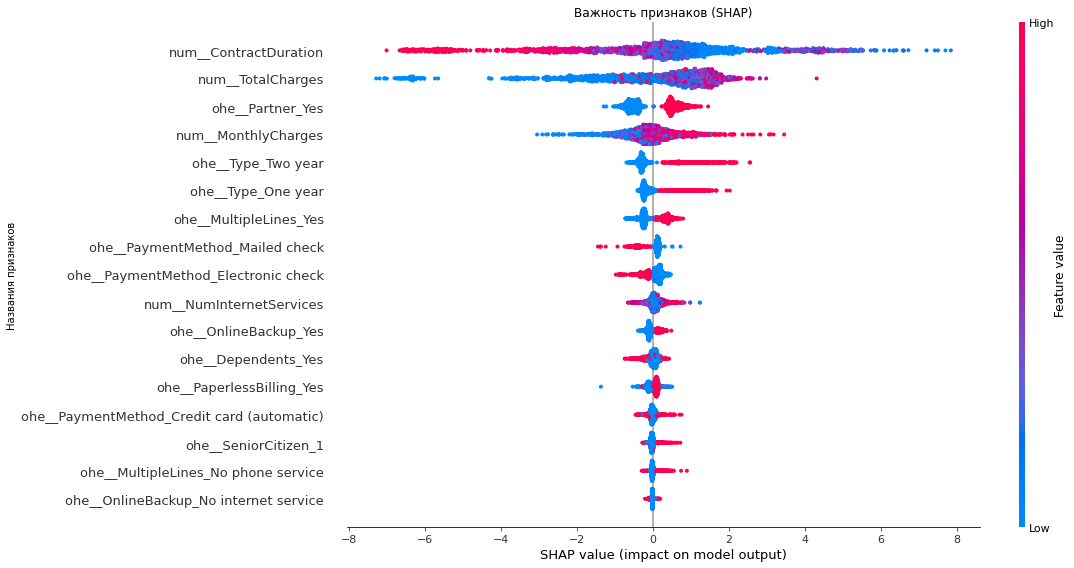

In [132]:
shap.summary_plot(
shap_values,
X_test_transformed,
feature_names=feature_names,
max_display=20,
plot_size=(16, 8),
show=False  
)

ax = plt.gca()
ax.set_title("Важность признаков (SHAP)")
ax.set_ylabel("Названия признаков")

plt.tight_layout()
plt.show()

**Вывод:**
1) Главный защитный фактор — длительность контракта
- Длинный стаж (красные точки слева) заметно снижает риск расторжения.
- Короткий стаж (синие точки справа) повышает риск.
Вывод: критичен онбординг и удержание в первые месяцы.

 2) Высокие ежемесячные платежи повышают риск
- Красные точки в основном справа → высокий monthly charge чаще толкает к расторжению.
Вывод: для дорогих тарифов нужны точечные офферы/ценность/скидки, особенно для клиентов с малым стажем.

 3) num__TotalCharges — признак с неоднозначным, сегментным влиянием
- Низкие значения часто снижают риск (синие слева)
- Синие точки так же наблюдаются справа, что ассоциировано с риском расторжения контракта, это может относиться к клиентам с низким стажем, у который на фоне этого низкое значение total charges
- Очень высокие значения у части клиентов резко повышают риск (красный хвост справа).
  Вывод: TotalCharges нельзя трактовать “монотонно”. Его нужно анализировать в связке с ContractDuration и MonthlyCharges.

 4) Тип контракта (one-hot ohe__Type_One year, ohe__Type_Two year)
- Длинные типы контракта выглядят как фактор повышения риска (точки смещены влево), а их отсутствие — как понижающий риск. На первый взгляд это выглядит нелогично, но эту же закономерность мы видели в исследовательском анализе. Скорее всего, длинные формы контрака невыгодны пользователям условиями расторжения и "пугают" их.
    Вывод: есть необходимость пересмотреть условия заключения длинных контрактов: повышение скидки, упростить условия расторжения, чтобы пользователям было выгодно и приятно ими пользоваться

 5) Социально-бытовые признаки (наличие партнера или иждивенцев, пенсионный возраст)
- Пенсионный возраст влияет незначительно, но чаще его достижение связано повышает риск оттока
- Наличие партнера повышает риск оттока, что может означать отсутствие у бизнеса семейных выгодных подписок и использование услуг конкурентов с этими услугами
- Наличие иждивенцев влияет нелинейно, сложно оценить его значение
 Вывод: стоит ввести социальные тарифы для пенсионеров со скидкой и семейные подписки 

 6) Способ оплаты 
- Автоматический платеж влияет незначительно, но чаще связан с оттоком, нежели другие способы оплаты

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

### Accuracy, матрица ошибок и их интерпретация

In [133]:
y_pred = model.predict(X_test)

In [134]:
accuracy_score(y_test, y_pred)

0.9443498012492901

Значение accuracy = 0.94, это значит, что в 94% модель верно предсказывает класс

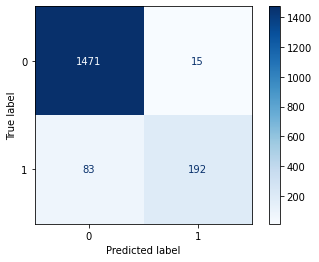

In [135]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()


Модель очень хорошо распознаёт класс 0: ошибок мало (15 FP при 1470 верных).
- По классу 1 ситуация хуже: есть заметное число пропусков (84 FN), то есть модель часто “не замечает” единицы и относит их к 0.
- Поэтому при высокой общей accuracy модель лучше “играет” на большинстве (класс 0), а качество по классу 1 ограничено.

Заказчику стоит сравнить свои убытки от потери клиентов и затраты на дополнительные промокоды и возможно будет смысл улучшать именно recall. Пока модель работает в пользу экономии на промокодах и акциях, избегая ошибочного определения класса 1 для клиента класса 0

<div class="alert alert-success">
<b>👍 Успех:</b> Все верно!
</div>

## Общий вывод:

В рамках этой работы я построила модель, которая помогает оператору связи «ТелеДом» заранее оценивать риск оттока — то есть предсказывать, разорвёт ли абонент договор или останется. Данные были разрознены по нескольким источникам, поэтому первым важным результатом стало аккуратное приведение их к единому виду: я корректно обработала даты, разобралась с нестандартными значениями (например, No в EndDate), создала целевой признак IsBrokenContract, привела числовые поля к нужным типам и отдельно разобрала ситуацию с пробелами в TotalCharges (это оказались новые клиенты на дату среза 01.02.2020, поэтому логично было заменить на 0). Также я проверила данные на дубликаты — проблем не обнаружилось.

После объединения таблиц по customerID я сформировала важный прикладной признак ContractDuration (длительность договора) и исключила поля, которые либо не несут смысла сами по себе, либо приводят к утечке таргета (например, EndDate). Пропуски, появившиеся после объединения, я интерпретировала корректно: если услуга не может быть подключена без интернета/телефонии, значит пропуск — это фактически “услуги нет”, поэтому заполнила их как No internet service / No phone service.

Дальше я провела исследовательский анализ объединённого датасета и подтвердила несколько логичных закономерностей: целевой класс сильно несбалансирован (около 15.6% оттока), а наиболее “сильные” признаки ожидаемо лежат в зоне поведения и продукта — тип договора, платежные привычки, стоимость тарифа, набор подключенных услуг и стаж клиента. Одновременно я проверила корреляции и снизила шум: убрала gender как слабосвязанный признак и аккуратно разобралась с мультиколлинеарностью среди интернет-услуг, оставив более информативную часть (например, OnlineBackup) и добавив агрегат NumInternetServices, чтобы сохранить смысл “насыщенности” услуг без раздувания признакового пространства.

Подготовку данных я оформила пайплайном: числовые признаки масштабировала, категориальные — кодировала (one-hot) .Это позволило корректно обучать модели без ручных “костылей” и снижало риск ошибок при воспроизводимости.

В качестве моделей я сравнила как базовые решения (логистическая регрессия, дерево), так и более сильные градиентные алгоритмы (CatBoost и LGBM). Лучший результат дала модель CatBoost после подбора гиперпараметров (learning_rate=0.07, iterations=3000, depth=4): целевая метрика получилась около 0.916 на подборе и около 0.92 на тесте, то есть выше требуемого порога 0.85. Дополнительно я проверила адекватность через dummy-модели (результат около 0.5), и на этом фоне стало понятно, что модель действительно учится закономерностям, а не “угадывает”.

Отдельно я разобрала важность признаков и получила выводы, которые можно напрямую использовать в бизнесе:
- самый сильный “защитный” фактор — длительность отношений с клиентом: чем дольше клиент с компанией, тем ниже риск, а первые месяцы/год критичны для удержания;
- высокий MonthlyCharges повышает риск — дорогим тарифам нужны более понятные ценностные предложения и точечные удерживающие офферы, особенно для клиентов с небольшим стажем;
- TotalCharges ведёт себя не монотонно и лучше работает как сегментный показатель — его нельзя трактовать в отрыве от длительности и ежемесячного платежа;
- тип контракта тоже даёт важный сигнал, и по моим наблюдениям есть повод отдельно пересмотреть “длинные” контракты с точки зрения условий, выгоды и удобства расторжения, чтобы они не выглядели для клиента риском;
- соц-демо признаки (пенсионный возраст, наличие партнёра/иждивенцев) дают дополнительные эффекты и могут подсказать направление для продуктовых решений вроде семейных подписок и социальных тарифов.

При этом по матрице ошибок видно важное ограничение: модель очень уверенно распознаёт класс “не уйдёт”, но часть уходящих клиентов она пропускает (есть заметные FN). То есть текущая настройка скорее экономит бюджет на промокоды (меньше ложных тревог), но не максимизирует полноту поиска “уходящих”. В реальном внедрении я бы рекомендовала принимать решение, что для бизнеса дороже: потерять клиента или дать лишнюю скидку, и уже под это двигать порог классификации/оптимизировать recall по классу 1.

В итоге я получила рабочую и адекватную модель с качеством выше целевого, понятной интерпретацией ключевых факторов оттока и практическими рекомендациями, которые можно использовать для удержания: фокус на раннем стаже, на клиентах с высокими ежемесячными платежами, и на пересборке предложений/условий там, где продуктовые параметры статистически “толкают” к расторжению.


**РЕКОМЕНДАЦИИ БИЗНЕСУ:**

Фокус на удержании в первые месяцы/первый год
- Сделать “онбординг-цепочку”: серия касаний в первые 7/30/90 дней (проверка качества связи, помощь с настройкой, предложение полезных сервисов).
- Ввести триггеры риска для новых клиентов: если клиент на помесячном тарифе и с высоким MonthlyCharges — автоматически отправлять персональный оффер/звонок.
- Отдельно контролировать жалобы/обращения в поддержку в этот период (если такие данные появятся — это будет очень сильный признак).

Для дорогих тарифов — точечные предложения вместо массовых скидок
- Для клиентов с высоким MonthlyCharges делать “пакеты ценности”: не просто скидку, а бонусы, которые повышают ощущение выгоды (доп. сервисы, ускорение интернета, расширенная поддержка).
- Протестировать “гарантию цены” на 3–6 месяцев или временную скидку при риске ухода (лучше ограниченную по времени).
- Разделить офферы по стажу: дорогой тариф + маленький стаж = приоритет №1 на удержание.

Пересмотреть логику долгосрочных контрактов (1–2 года)  

Так как по моим наблюдениям есть сигнал, что длинные контракты могут восприниматься негативно/как “ловушка”, я бы предложила:
- Сделать условия расторжения прозрачнее и мягче (например, без сложных штрафов, с понятной формулой).
-  Усилить стимулы: заметная скидка относительно помесячного тарифа, бонусы за продление, “подарок” при переходе на 1–2 года.
- Коммуникацию поменять с “подпишись на 2 года” на “зафиксируй условия и получай выгоду”, то есть продавать это как снижение рисков клиента.

Работа с оплатой и платежными привычками
- По клиентам с ручными/неустойчивыми методами оплаты (в т.ч. electronic check) — мягко переводить на автоплатёж: бонус за подключение автоплатежа, напоминания, упрощение процесса.
- Важно: автоплатёж сам по себе не “лекарство”, но он снижает трение и может уменьшать спонтанный отток (когда клиент уходит “потому что надоело/не оплатил”).

Сегментация по “ценности” и стажу (TotalCharges + ContractDuration)
- Дорогих в удержании клиентов (длинный стаж/высокая ценность) не стоит “заливать” скидками без причины — лучше сервис, приоритетная поддержка, индивидуальные условия.
- Клиентов со средним стажем, где риск выше (примерно 1.5–4 года по моим наблюдениям), имеет смысл регулярно “перезапускать” выгодой: бонус за лояльность, обновление тарифа, апгрейд условий.

Продуктовые пакеты: семейные и социальные
Раз есть сигнал по Partner/частично SeniorCitizen, я бы протестировала:
- семейные подписки (2–3 номера/услуги в пакете дешевле, общий счёт, общий бонус);
- “социальный” тариф для пенсионеров (простые условия, понятная скидка, приоритетная поддержка).  
    Это может снижать риск ухода за счёт ощущения справедливой цены и “подходящего” предложения.

Операционная рекомендация: работать не только “моделью”, но и порогом  
  Сейчас модель лучше избегает ложных срабатываний, но может пропускать часть уходящих (FN). Для бизнеса это означает:
- настроить порог решения под экономику: сколько стоит потеря клиента vs стоимость промокода;
- сделать 2 режима:
  - “дешёвое удержание” (SMS/пуш/малый бонус) — можно давать более широкому сегменту (выше recall);
  - “дорогое удержание” (персональный менеджер/существенная скидка) — только топ‑рисковым (выше precision).

<div class="alert alert-success">
<b>👍 Успех:</b> Молодец, финальный проект завершен! Сама работа получилась хорошей и структурированной, были предобработаны и проанализированы данные, выбран целевой признак, рассчеты подкреплены визуализацией, это очень важная часть работы, которая облегчает анализ и позволяет полнее представлять происходящее в данных. Построено и обучено несколько моделей, все они оценены и выбрана лучшая. Цель работы достигнута, получена модель хорошо предсказывающая уход клиентов. Не забывай о том, что все пункты очень важны и каждому стоит уделять максимум внимания. <p>
С опытом становится значительно легче, но опыт это не только повторение однажды изученного, но и постоянное развитие, тем более, что ты выбрала очень динамично развивающуюся область. <p>
В будущей профессии тебе точно пригодиться умение системно подходить к решению аналитических задач, здесь рекомендую изучить ТРИЗ и системный анализ, из литературы можно почитать Теоретический минимум по Big Data — Су Кеннет и Ын Анналин, Практическая статистика для специалистов Data Science — Брюс П. и Брюс Э., Real-World Machine Learning — Henric Brink, Joseph Мark, W. Richards Fetherolf, Прикладное машинное обучение с помощью Scikit-Learn и TensorFlow — Жерон Орельен.<p>
Есть интересные сообщества (например https://vk.com/mashinnoe_obuchenie_ai_big_data) и конечно же https://habr.com/ru/all/<p>

Дополнительно предлагаю посмотреть:
- Книга от ШАД: https://academy.yandex.ru/handbook/ml

- Открытый курс машинного обучения: https://habr.com/ru/company/ods/blog/322626/

 Удачи тебе и профессионального роста!
</div>